<a href="https://colab.research.google.com/github/Praneetreddy9156/Test4/blob/main/cvfilters7march.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving new img.jpg to new img.jpg

IMAGE PROCESSING MENU
1 Translation
2 Rotation
3 Scaling
4 Shearing
5 Point Filter
6 Mean Filter
7 Median Filter
8 Affine Transform
0 Exit
Enter choice: 3
Enter scale x: 3
Enter scale y: 4


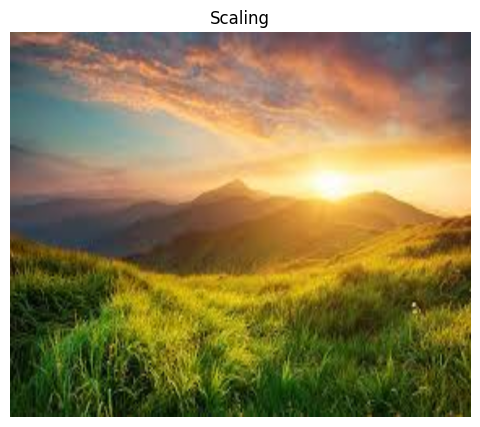


IMAGE PROCESSING MENU
1 Translation
2 Rotation
3 Scaling
4 Shearing
5 Point Filter
6 Mean Filter
7 Median Filter
8 Affine Transform
0 Exit
Enter choice: 5
Enter constant value: 4


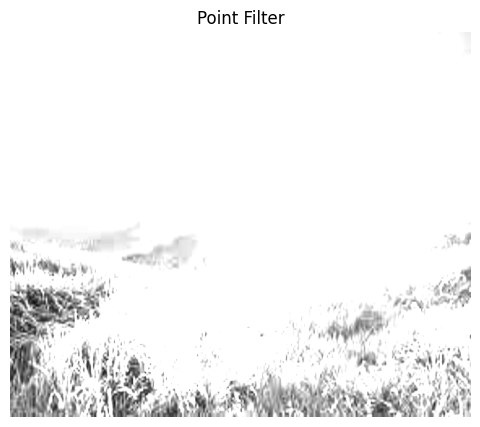


IMAGE PROCESSING MENU
1 Translation
2 Rotation
3 Scaling
4 Shearing
5 Point Filter
6 Mean Filter
7 Median Filter
8 Affine Transform
0 Exit
Enter choice: 8

Affine Transformations
1 Rotation
2 Scaling
3 Shearing
4 Translation
5 Apply
0 Back
Choice: 1
angle: 45

Affine Transformations
1 Rotation
2 Scaling
3 Shearing
4 Translation
5 Apply
0 Back
Choice: 5


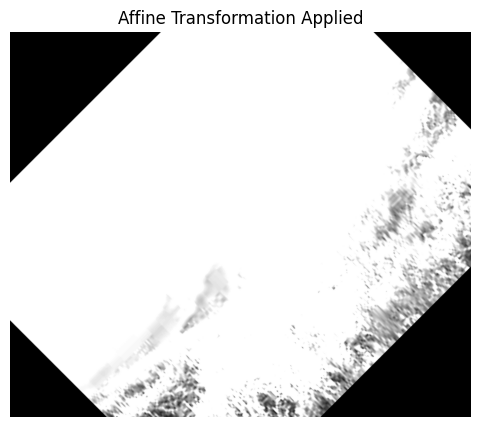


IMAGE PROCESSING MENU
1 Translation
2 Rotation
3 Scaling
4 Shearing
5 Point Filter
6 Mean Filter
7 Median Filter
8 Affine Transform
0 Exit


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files

class ImageProcessor:

    def __init__(self, image_path):
        self.image_path = image_path
        self.img = cv2.imread(image_path)

    # display image
    def show(self,title="Image"):
        plt.figure(figsize=(6,5))
        plt.imshow(cv2.cvtColor(self.img,cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
        plt.show()

    # ---------------- FILTERS ----------------

    def point_filter(self):
        c=float(input("Enter constant value: "))
        gray=cv2.cvtColor(self.img,cv2.COLOR_BGR2GRAY)
        gray=np.clip(gray*c,0,255).astype(np.uint8)
        self.img=cv2.cvtColor(gray,cv2.COLOR_GRAY2BGR)
        self.show("Point Filter")

    def mean_filter(self):
        k=int(input("Enter kernel size (3 or 5): "))
        self.img=cv2.blur(self.img,(k,k))
        self.show("Mean Filter")

    def median_filter(self):
        k=int(input("Enter kernel size (3 or 5): "))
        self.img=cv2.medianBlur(self.img,k)
        self.show("Median Filter")

    # ---------------- GEOMETRIC ----------------

    def translate(self):
        tx=int(input("Enter translate x: "))
        ty=int(input("Enter translate y: "))

        rows,cols=self.img.shape[:2]
        M=np.float32([[1,0,tx],[0,1,ty]])

        self.img=cv2.warpAffine(self.img,M,(cols,rows))
        self.show("Translation")

    def rotate(self):
        angle=float(input("Enter rotation angle: "))

        rows,cols=self.img.shape[:2]
        M=cv2.getRotationMatrix2D((cols//2,rows//2),angle,1)

        self.img=cv2.warpAffine(self.img,M,(cols,rows))
        self.show("Rotation")

    def scale(self):
        sx=float(input("Enter scale x: "))
        sy=float(input("Enter scale y: "))

        rows,cols=self.img.shape[:2]

        self.img=cv2.resize(self.img,(int(cols*sx),int(rows*sy)))
        self.show("Scaling")

    def shear(self):
        sh=float(input("Enter shear value: "))

        rows,cols=self.img.shape[:2]
        M=np.float32([[1,sh,0],[0,1,0]])

        self.img=cv2.warpAffine(self.img,M,(cols,rows))
        self.show("Shearing")

    # ---------------- AFFINE ----------------

    def affine_transform(self):

        matrix=np.eye(3)

        while True:

            print("\nAffine Transformations")
            print("1 Rotation")
            print("2 Scaling")
            print("3 Shearing")
            print("4 Translation")
            print("5 Apply")
            print("0 Back")

            ch=int(input("Choice: "))

            if ch==1:
                angle=float(input("angle: "))
                rows,cols=self.img.shape[:2]
                center=(cols//2,rows//2)

                rot=cv2.getRotationMatrix2D(center,angle,1)
                rot=np.vstack([rot,[0,0,1]])

                matrix=rot@matrix

            elif ch==2:
                sx=float(input("scale x: "))
                sy=float(input("scale y: "))

                scale=np.array([[sx,0,0],
                                [0,sy,0],
                                [0,0,1]])

                matrix=scale@matrix

            elif ch==3:
                shx=float(input("shear x: "))
                shy=float(input("shear y: "))

                shear=np.array([[1,shx,0],
                                [shy,1,0],
                                [0,0,1]])

                matrix=shear@matrix

            elif ch==4:
                tx=float(input("translate x: "))
                ty=float(input("translate y: "))

                trans=np.array([[1,0,tx],
                                [0,1,ty],
                                [0,0,1]])

                matrix=trans@matrix

            elif ch==5:

                rows,cols=self.img.shape[:2]
                final=matrix[:2,:]

                self.img=cv2.warpAffine(self.img,final,(cols,rows))

                self.show("Affine Transformation Applied")
                break

            elif ch==0:
                break

    # ---------------- MENU ----------------

    def menu(self):

        while True:

            print("\n==============================")
            print("IMAGE PROCESSING MENU")
            print("==============================")

            print("1 Translation")
            print("2 Rotation")
            print("3 Scaling")
            print("4 Shearing")
            print("5 Point Filter")
            print("6 Mean Filter")
            print("7 Median Filter")
            print("8 Affine Transform")
            print("0 Exit")

            ch=int(input("Enter choice: "))

            if ch==1:
                self.translate()

            elif ch==2:
                self.rotate()

            elif ch==3:
                self.scale()

            elif ch==4:
                self.shear()

            elif ch==5:
                self.point_filter()

            elif ch==6:
                self.mean_filter()

            elif ch==7:
                self.median_filter()

            elif ch==8:
                self.affine_transform()

            elif ch==0:
                print("Exiting...")
                break


# ---------------- IMAGE UPLOAD ----------------

uploaded = files.upload()

for filename in uploaded.keys():
    full_path=os.path.abspath(filename)

processor=ImageProcessor(full_path)

processor.menu()